# Import and Function Definition

In [5]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import os, sys, pickle, glob
import qutip as qt
import textwrap
import experiments as meas

from copy import deepcopy
from collections import defaultdict
from tqdm.notebook import tqdm
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner


REPO_ROOT = r"C:\python\multimode_expts" 
RUN_PREFIX = "JOB-20260414"  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
dir(whatisthis)

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'completed_at',
 'created_at',
 'data_file_path',
 'error_message',
 'experiment_class',
 'expt_pickle_path',
 'floquet_storage_version_id',
 'from_dict',
 'hardware_config_version_id',
 'is_done',
 'is_successful',
 'job_id',
 'load_expt',
 'man1_storage_version_id',
 'multiphoton_config_version_id',
 'queue_position',
 'started_at',
 'status',
 'user']

In [25]:
whatisthis = query_which_config_used(h5_spectroscopy_job_ids[0])
whatisthis.floquet_storage_version_id

JobResult(job_id='JOB-20260825-00047', status='completed', user='jonginn', experiment_class='EncodingHamiltonianSpectroscopyExperiment', created_at=datetime.datetime(2026, 8, 25, 2, 42, 3, 582733), started_at=datetime.datetime(2026, 8, 25, 2, 42, 4, 121259), completed_at=datetime.datetime(2026, 8, 25, 2, 48, 46, 272061), data_file_path='C:\\experiments\\260818_qsim_spectroscopy\\data\\JOB-20260825-00047_EncodingHamiltonianSpectroscopyExperiment.h5', expt_pickle_path='C:\\experiments\\260818_qsim_spectroscopy\\expt_objs\\JOB-20260825-00047_expt.pkl', error_message=None, queue_position=None, hardware_config_version_id='CFG-HW-20260824-00001', multiphoton_config_version_id='CFG-MP-20260121-00001', floquet_storage_version_id='CFG-FL-20260824-00073', man1_storage_version_id='CFG-M1-20260824-00011')


'CFG-FL-20260824-00073'

In [27]:
from dataclasses import asdict
from job_server import JobClient
from experiments.qsim.mbr_campaign import config_set_for_job

def query_which_config_used(job_id):
    _job_result = JobClient().get_status(job_id)
    config_list = [_job_result.hardware_config_version_id,
                   _job_result.man1_storage_version_id,
                   _job_result.floquet_storage_version_id,
                   _job_result.multiphoton_config_version_id,]
    if print:
        print(config_list)
    return config_list


# Helper Functions & Definitions

Run this section once (after the import cell). All later sections only call these -- no section depends on another.

In [6]:
import numpy as np


def common_grid_jobs(headers):
    # Preserve every saved job in the manifest. Only the rectangular analysis
    # aggregate excludes orphan/short rows; raw preview can still show those jobs.
    grouped = {}
    for header in headers:
        cfg = header.cfg.expt
        initial = tuple(cfg.spectroscopy_occupations)
        final = tuple(cfg.get('offdiag_decoder_occupation', cfg.get('spectroscopy_final_occupations', initial)))
        grouped.setdefault((final, initial), []).append(header)
    valid, excluded = {}, []
    for pair, chunks in grouped.items():
        grids = {}
        for header in chunks:
            cfg = header.cfg.expt
            phases = (0., 90.) if 'offdiag_cycles' in cfg else (float(cfg.spectroscopy_analyzer_phase),)
            for phase in phases:
                grids.setdefault(phase, []).extend(cfg.get('offdiag_cycles', cfg.get('floquet_cycles', [])))
        first = tuple(sorted(grids.get(0., [])))
        second = tuple(sorted(grids.get(90., [])))
        regular = len(first) < 3 or len(set(np.diff(first))) == 1
        if not first or first != second or len(set(first)) != len(first) or first[0] != 0 or not regular:
            excluded.extend(dict(job_id=item.job_id, reason='orphan, duplicate, or unequal analyzer/cycle coverage') for item in chunks)
        else:
            valid[pair] = (first, chunks)
    if not valid:
        return [], excluded, []
    # Longest available contiguous grid starting at zero, selected without looking
    # at amplitudes, fitted peaks, or theory. Do not silently trim long rows.
    grid = max((value[0] for value in valid.values()), key=len)
    kept = []
    for row_grid, chunks in valid.values():
        if row_grid == grid:
            kept.extend(item.job_id for item in chunks)
        else:
            excluded.extend(dict(job_id=item.job_id, reason='short row: differs from longest saved cycle grid') for item in chunks)
    return sorted(kept), excluded, list(grid)


# Saved HDF5 data: self-contained dataset and disorder-series cells

Run the **Helper Functions & Definitions**, **path settings**, and **HDF5 helpers** cells once. Each data cell below declares its calibration and spectroscopy job IDs or ranges.
Disorder-series cells list the spectroscopy IDs for every realization and show
their spectra in grouped figures.
That same cell loads its local Floquet station settings when available, reads
only those HDF5 jobs, and calls `analyze()` and `display()`. Run any one data
cell independently of the other data cells. The shared helpers do not select
or load any job, station, or dataset-wide hardware.

T/g comes from saved HDF5 hardware or the verified acquisition Floquet CSV.
If neither is available, the cell stops before plotting a frequency axis or theory.
The HDF5 experiment data come directly from local files. No instrument server
is contacted, and nothing is exported.


In [7]:
# Shared path only. Every data cell below declares and loads its own hardware.
BASE_DIR = r"C:\experiments" #r"S:\Multimode\BF5_expts_autosync" #r"C:\experiments"  # PROJECT/data/JOB-....h5


In [8]:
# HDF5 analysis/display helpers; no JobClient, pickle, or output files.
import json
import math
from collections import Counter
from pathlib import Path
from types import SimpleNamespace
from time import perf_counter

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display as notebook_display
from slab import AttrDict
from experiments.qsim.deprecated.legacy_mbr import (
    MBRPhaseCorrectionExperiment, MBRSpectrumExperiment,
)

if "common_grid_jobs" not in globals():
    raise RuntimeError("Run the Helper Functions & Definitions cell first")
if "BASE_DIR" not in globals():
    raise RuntimeError("Run the path settings cell first")

# HDF5 reconstruction definitions used by this notebook.
def make_plain(value):
    if hasattr(value, 'tolist'):
        value = value.tolist()
    if isinstance(value, dict):
        return {str(key): make_plain(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_plain(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def parameter_key(value):
    return json.dumps(make_plain(value), sort_keys=True, allow_nan=False)


def saved_parameters(expt):
    # These parameters really are in H5. Pulse-CSV values and RFSoC clocks
    # were NOT included in older H5 files, and cannot be inferred from job names.
    ecfg = expt.cfg.expt
    modes = list(map(int, ecfg.swap_stors))
    man = int(ecfg.get('man_mode_no', 1))
    kerr = np.asarray(expt.cfg.device.manipulate.kerr).reshape(-1)
    return dict(photon_number=sum(ecfg.spectroscopy_occupations), 
                swap_stors=modes,
                physical_kerr_MHz=-abs(float(kerr[min(man - 1, len(kerr) - 1)])),
                man_mode_no=man, 
                floquet_waveform=ecfg.get('floquet_waveform'),
                scramble_sync_cycles=int(ecfg.get('scramble_sync_cycles', 10)),
                floquet_gauss_sigma=ecfg.get('floquet_gauss_sigma'),
                use_multiphoton_swap=bool(ecfg.get('use_multiphoton_swap', False)))


class SavedHardwareMixin:
    """Use the archived hardware parameters for calibration and spectra."""

    @classmethod
    def _saved_parameters(cls, expts, station=None):
        first = expts[0]
        parameters = saved_parameters(first)
        metadata = getattr(first, 'saved_hardware', None)
        if not metadata or metadata.get('floquet_cycle_us') is None or metadata.get('couplings_MHz') is None:
            raise ValueError('This H5 has no archived cycle clock/couplings. Supply their historical values '
                             'in the dataset hardware settings; raw cycle-domain data are already loaded.')
        cycle_us = float(metadata['floquet_cycle_us'])
        coupling = np.asarray(metadata['couplings_MHz'], dtype=float)
        modes = parameters['swap_stors']
        if (cycle_us <= 0 or not np.isfinite(cycle_us) or coupling.shape != (len(modes),)
                or not np.isfinite(coupling).all() or np.any(coupling <= 0)):
            raise ValueError('Archived cycle time/couplings do not match the selected modes')
        detuning = cls._saved_detunings(first.cfg.expt, len(modes))
        for child in expts[1:]:
            if saved_parameters(child) != parameters:
                raise ValueError('Selected H5 jobs have different physical settings')
            if not np.array_equal(cls._saved_detunings(child.cfg.expt, len(modes)), detuning):
                raise ValueError('Selected H5 jobs have different disorder detunings')
            other = getattr(child, 'saved_hardware', None)
            if (not other or other.get('floquet_cycle_us') != cycle_us
                    or not np.array_equal(other.get('couplings_MHz'), coupling)):
                raise ValueError('Selected H5 jobs have different archived clocks/couplings')
        hardware = AttrDict(dict(floquet_cycle_us=cycle_us, couplings_MHz=coupling,
                                physical_kerr_MHz=parameters['physical_kerr_MHz'],
                                decoder_cycle_us=float(metadata.get('decoder_cycle_us', cycle_us)),
                                detunings_MHz=detuning.copy(), source=metadata['source']))
        return AttrDict(dict(swap_stors=modes, detunings=detuning,
                             mode_labels=['M1'] + [f'S{mode}' for mode in modes], hardware=hardware))


class SavedSpectroscopyExperiment(SavedHardwareMixin, MBRSpectrumExperiment):
    """Analyze old H5 spectra without initializing instruments."""

    @classmethod
    def _postprocess_reconstruction(cls, 
                                    reconstruction, 
                                    saved_correction, 
                                    calibration,
                                    hardware, 
                                    phase_frame,
                                    manual_kerr_MHz, 
                                    cycle_branches,
                                    legacy):
        
        result = super()._postprocess_reconstruction(reconstruction, 
                                                     saved_correction, 
                                                     calibration, 
                                                     hardware,
                                                     phase_frame, 
                                                     manual_kerr_MHz, 
                                                     cycle_branches, 
                                                     legacy)
        
        actual_us = float(hardware.floquet_cycle_us)
        decoder_us = float(hardware.get('decoder_cycle_us', actual_us))
        
        if np.isclose(decoder_us, actual_us, rtol=1e-9, atol=1e-12):
            return result
        if result.phase_frame != 'as_acquired':
            raise ValueError('Different archived decoder/physical clocks are validated here only for '
                             "phase_frame='as_acquired', manual_kerr_MHz=None")
        if saved_correction.application_sign != -1 or saved_correction.modes != {'final_analyzer'}:
            raise ValueError('The archived decoder-clock correction requires the recorded -1 final-analyzer convention')

        # DDS detuning acts for actual_us; the decoder advanced its reference phase
        # for decoder_us. Remove only their known difference, independently of peaks/H.
        corrected = result.reconstruction  # base method already copied the raw A.
        final = np.asarray(corrected.final_occupations)
        detunings = np.asarray(hardware.detunings_MHz)
        n_man = final[:, 0]
        reference_kerr = float(hardware.physical_kerr_MHz) * n_man * (n_man - 1) / 2
        # The saved gamma also included K*choose(n_M1,2)*T_decoder.
        # Use the same independently saved K, not a value fitted to peaks.
        turns_per_cycle = (decoder_us - actual_us) * (final[:, 1:] @ detunings - reference_kerr)
        rotation = np.exp(-2j * np.pi * turns_per_cycle[:, None] * corrected.cycles[None, :])
        corrected.A *= rotation
        corrected.A_norm = np.asarray([
            row / row[0] if tuple(initial) == tuple(final_state) else row
            for row, initial, final_state in zip(corrected.A, corrected.occupations, corrected.final_occupations)
        ])
        result.decoder_clock_correction = AttrDict(dict(
            decoder_cycle_us=decoder_us, physical_cycle_us=actual_us,
            turns_per_cycle=turns_per_cycle, source=hardware.source))
        return result


def load_h5(header, hardware=None, cache=None, load_shots=False):
    path = Path(header.fname)
    fingerprint = (str(path.resolve()), path.stat().st_size, path.stat().st_mtime_ns,
                   parameter_key(hardware), bool(load_shots))
    if cache is not None and fingerprint in cache:
        return cache[fingerprint]
    # Same __new__ + config/data reconstruction as Experiment.from_h5file,
    # but do not load gigabytes of single shots just to plot averaged spectra.
    expt = SavedSpectroscopyExperiment.__new__(SavedSpectroscopyExperiment)
    expt.fname = str(path)
    with h5py.File(path, 'r') as handle:
        expt.cfg = AttrDict(json.loads(handle.attrs['config']))
        expt.data = AttrDict({name: np.asarray(value) for name, value in handle.items()
                             if load_shots or name not in ('idata', 'qdata')})
        expt.data['attrs'] = dict(handle.attrs)
    expt.path, expt.config_file, expt.prefix = str(path.parent), str(path), path.stem
    expt.job_id = header.job_id
    expt.saved_hardware = header.saved_hardware or hardware
    if cache is not None:
        cache[fingerprint] = expt
    return expt


def h5_job_ids(date, first, last, step=1):
    return [f"JOB-{date}-{number:05d}" for number in range(first, last + 1, step)]


def h5_header(path):
    # Older H5 files may omit shot arrays. Only averaged data are needed here.
    with h5py.File(path, "r") as handle:
        cfg = AttrDict(json.loads(handle.attrs["config"]))
        ecfg = cfg.expt
        if "n_cycle_pairs" in ecfg and (len(ecfg.get("floquet_cycles", [0])) < 2):
            kind = "calibration"
        elif "spectroscopy_occupations" in ecfg and (
            "floquet_cycles" in ecfg or "offdiag_cycles" in ecfg
        ):
            kind = "spectroscopy"
        else:
            raise ValueError("unrelated HDF5 experiment")
        if not all(key in handle for key in ("avgi", "xpts", "ypts")):
            raise ValueError("HDF5 averages or sweep axes are incomplete")
        hardware = None
        if "spectroscopy_hardware" in handle.attrs:
            hardware = json.loads(handle.attrs["spectroscopy_hardware"])
            hardware["source"] = f"HDF5: {path.name}"
    return SimpleNamespace(
        cfg=cfg, fname=str(path), kind=kind, job_id=path.name[:18],
        saved_hardware=hardware,
    )


def h5_headers_for_ids(directory, job_ids, kind, search_other_projects=False):
    directory = Path(directory)
    root = Path(BASE_DIR)
    if not root.is_dir():
        raise FileNotFoundError(f"HDF5 base directory does not exist: {root}")
    found = {}
    first_rejection = None

    def consider(path, job_id):
        nonlocal first_rejection
        try:
            header = h5_header(path)
        except (OSError, KeyError, ValueError, TypeError) as error:
            if first_rejection is None:
                first_rejection = f"{path.name}: {error}"
            return
        if header.kind != kind:
            return
        if job_id in found and found[job_id].fname != header.fname:
            raise ValueError(f"{job_id}: multiple {kind} HDF5 files")
        found[job_id] = header

    # One directory scan per date avoids repeating a network glob for every job.
    requested_by_date = {}
    for job_id in job_ids:
        requested_by_date.setdefault(job_id[:12], set()).add(job_id)
    for date_prefix, requested_ids in requested_by_date.items():
        pattern = (f"{date_prefix}-*.h5" if len(requested_ids) > 1
                   else f"{next(iter(requested_ids))}_*.h5")
        for path in directory.glob(pattern):
            job_id = path.name[:18]
            if job_id in requested_ids:
                consider(path, job_id)

    # Older manifests omit the project. Search each other project at most
    # once per job date, instead of scanning every project for every job ID.
    unresolved = set(job_ids) - set(found)
    if search_other_projects and unresolved:
        folders = [
            item / "data" for item in root.iterdir()
            if item.is_dir() and (item / "data").is_dir()
            and item / "data" != directory
        ]
        for folder in folders:
            if not unresolved:
                break
            date_prefixes = {job_id[:12] for job_id in unresolved}
            for prefix in date_prefixes:
                for path in folder.glob(f"{prefix}-*.h5"):
                    job_id = path.name[:18]
                    if job_id in unresolved:
                        consider(path, job_id)
                        if job_id in found:
                            unresolved.remove(job_id)
    if not found and first_rejection is not None:
        print(f"  HDF5 files were found but their headers were rejected: {first_rejection}")
    return found


def h5_physical_key(header):
    return parameter_key(saved_parameters(header))


def h5_group_key(header):
    ecfg = header.cfg.expt
    return parameter_key(dict(
        physical=saved_parameters(header),
        detunings=ecfg.get("detunings", []),
    ))


def h5_paired_calibration_ids(headers):
    phases = {}
    for job_id, header in headers.items():
        ecfg = header.cfg.expt
        occupation = tuple(ecfg.spectroscopy_occupations)
        phase = float(ecfg.spectroscopy_analyzer_phase)
        phases.setdefault(occupation, {0.0: [], 90.0: []})
        if phase in (0.0, 90.0):
            phases[occupation][phase].append(job_id)
    return [
        job_id
        for pair in phases.values()
        if pair[0.0] and len(pair[0.0]) == len(pair[90.0])
        for job_id in pair[0.0] + pair[90.0]
    ]


class H5CalibrationExperiment(SavedHardwareMixin, MBRPhaseCorrectionExperiment):
    """Analyze old H5 calibration jobs and show the phase summary."""

    def display(self, data=None):
        if data is not None:
            self.data = data
        return self.display_calibration_summary(self.data)


class H5LegacyPlusExperiment(SavedSpectroscopyExperiment):
    """Keep the July 21 raw N=2 cell's Q(0)+iQ(90) convention."""

    @classmethod
    def reconstruct_spectroscopy(cls, expts, occupations=None):
        result = super().reconstruct_spectroscopy(expts, occupations)
        result.A = np.conj(result.A)
        result.A_norm = np.conj(result.A_norm)
        return result


# Construct only the local configuration needed for T/g. No instrument proxy.
def h5_load_offline_station(version_id):
    if version_id is None:
        return None
    from experiments.dataset import FloquetStorageSwapDataset
    csv_path = (
        Path(FloquetStorageSwapDataset.repo_root) / "configs" / "versions"
        / "floquet_storage_swap" / f"{version_id}.csv"
    )
    if not csv_path.is_file():
        # HDF5 may already contain T/g; defer the missing CSV error until needed.
        return SimpleNamespace(version_id=version_id, csv_path=csv_path,
                               ds_floquet=None, soccfg=None)
    from experiments.station import read_soccfg_snapshot
    station = SimpleNamespace(
        ds_floquet=FloquetStorageSwapDataset(csv_path.name, csv_path.parent),
        soccfg=read_soccfg_snapshot(),
        version_id=version_id,
        source=str(csv_path),
        hardware_cache={},
    )
    print(f"  station config: {version_id} (local CSV + RFSoC clock snapshot)")
    return station


def h5_ds_floquet_hardware(header, dataset_name, station):
    if station is None:
        return None
    if station.ds_floquet is None:
        raise FileNotFoundError(
            f"{dataset_name}: Floquet config version {station.version_id} "
            f"is missing: {station.csv_path}"
        )
    ecfg = header.cfg.expt
    modes = list(map(int, ecfg.swap_stors))
    recorded_cycle = ecfg.get("floquet_cycle_us")
    if recorded_cycle is not None:
        # The acquisition program saved its actual compiled cycle time in HDF5.
        cycle_us = float(recorded_cycle)
        pi_fracs = np.asarray([
            station.ds_floquet.get_pi_frac(f"M1-S{stor}") for stor in modes
        ], dtype=float)
        if (not np.isfinite(cycle_us) or cycle_us <= 0
                or not np.isfinite(pi_fracs).all() or np.any(pi_fracs <= 0)):
            raise ValueError(f"{dataset_name}: invalid saved cycle time or Floquet pi fractions")
        couplings = 1.0 / (4.0 * pi_fracs * cycle_us)
        source = f"HDF5 expt.floquet_cycle_us + Floquet CSV {station.version_id}"
    else:
        # Reuse the experiment class's pulse and clock calculation when HDF5
        # predates the saved cycle time. The CSV must be the acquisition version.
        offline_station = SimpleNamespace(
            hardware_cfg=header.cfg,
            ds_floquet=station.ds_floquet,
            soccfg=station.soccfg,
        )
        hardware = MBRSpectrumExperiment.hardware_parameters(
            offline_station, modes,
            int(ecfg.get("scramble_sync_cycles", 10)),
            ecfg.get("floquet_gauss_sigma"),
            ecfg.get("floquet_waveform"),
        )
        cycle_us = float(hardware.floquet_cycle_us)
        couplings = np.asarray(hardware.couplings_MHz, dtype=float)
        source = f"Floquet CSV {station.version_id} + HDF5 config + RFSoC clock"
    result = dict(
        floquet_cycle_us=cycle_us,
        couplings_MHz=couplings.tolist(),
        source=source,
    )
    if ecfg.get("decoder_cycle_us") is not None:
        result["decoder_cycle_us"] = float(ecfg.decoder_cycle_us)
    return result


def h5_hardware_for(header, dataset_name, station=None):
    if header.saved_hardware is not None:
        return header.saved_hardware
    hardware = h5_ds_floquet_hardware(header, dataset_name, station)
    if hardware is not None:
        return hardware
    raise ValueError(
        f"{dataset_name}, {header.job_id}: no saved T/g in HDF5 and no verified "
        "Floquet config version. Cannot plot a frequency axis or theory with "
        "invented hardware values."
    )


def h5_load_group(
    name, project, calibration_ids, spectroscopy_ids, *,
    station=None, legacy_plus=False, search_other_projects=False,
    spectroscopy_headers=None, calibration_headers=None, calibration_cache=None,
):
    # Optional preloaded headers and calibration cache support grouped runs.
    directory = Path(BASE_DIR) / project / "data"
    print(f"\n{name}: locating {len(spectroscopy_ids)} spectroscopy HDF5 jobs", flush=True)
    lookup_started = perf_counter()
    headers = (
        h5_headers_for_ids(directory, spectroscopy_ids, "spectroscopy", search_other_projects)
        if spectroscopy_headers is None else {
            job_id: spectroscopy_headers[job_id] for job_id in spectroscopy_ids
            if job_id in spectroscopy_headers
        }
    )
    print(f"  spectroscopy headers: {len(headers)}/{len(spectroscopy_ids)} "
          f"in {perf_counter() - lookup_started:.1f}s", flush=True)
    if not headers:
        print("  no spectroscopy HDF5 files found")
        return None, None, None
    keys = Counter(h5_group_key(header) for header in headers.values())
    chosen_key = keys.most_common(1)[0][0]
    mixed_count = len(headers) - keys[chosen_key]
    if mixed_count:
        print(f"  excluded {mixed_count} jobs with different physical settings or detunings", flush=True)
    headers = {
        job_id: header for job_id, header in headers.items()
        if h5_group_key(header) == chosen_key
    }
    selected_ids, excluded, _ = common_grid_jobs(list(headers.values()))
    if not selected_ids:
        print("  no paired, common-cycle spectroscopy traces")
        return None, None, None
    selected = [headers[job_id] for job_id in selected_ids]
    physical_key = h5_physical_key(selected[0])

    calibration = None
    if calibration_ids:
        calibration_headers = (
            h5_headers_for_ids(directory, calibration_ids, "calibration", search_other_projects)
            if calibration_headers is None else {
                job_id: calibration_headers[job_id] for job_id in calibration_ids
                if job_id in calibration_headers
            }
        )
        matching = {
            job_id: header for job_id, header in calibration_headers.items()
            if h5_physical_key(header) == physical_key
        }
        paired_ids = h5_paired_calibration_ids(matching)
        cache_key = (physical_key, tuple(paired_ids))
        if calibration_cache is not None and cache_key in calibration_cache:
            calibration = calibration_cache[cache_key]
            print(f"  calibration: reused {len(paired_ids)} HDF5 jobs", flush=True)
        elif paired_ids:
            calibration_children = [
                load_h5(
                    matching[job_id],
                    h5_hardware_for(matching[job_id], name, station),
                    load_shots=False,
                )
                for job_id in paired_ids
            ]
            calibration = H5CalibrationExperiment._from_expts(
                calibration_children, job_ids=paired_ids
            )
            print(f"  calibration: loaded {len(paired_ids)} HDF5 jobs", flush=True)
            if calibration_cache is not None:
                calibration_cache[cache_key] = calibration
        else:
            print("  calibration: no matching paired HDF5 jobs", flush=True)
            if calibration_cache is not None:
                calibration_cache[cache_key] = None

    load_started = perf_counter()
    children = [
        load_h5(header, h5_hardware_for(header, name, station),
                load_shots=False)
        for header in selected
    ]
    print(f"  spectroscopy arrays: {len(children)} "
          f"in {perf_counter() - load_started:.1f}s", flush=True)
    experiment_class = H5LegacyPlusExperiment if legacy_plus else SavedSpectroscopyExperiment
    spectroscopy = experiment_class._from_expts(children, job_ids=selected_ids)
    sources = sorted({child.saved_hardware["source"] for child in children})
    print(f"  spectroscopy: loaded {len(selected_ids)} HDF5 jobs", flush=True)
    print("  T/g source: " + "; ".join(sources[:2]), flush=True)
    if excluded:
        print(f"  excluded {len(excluded)} short/orphan HDF5 jobs")
    info = AttrDict(dict(
        name=name, selected_count=len(selected_ids),
        requested_count=len(spectroscopy_ids),
        completion=("PARTIAL acquisition" if len(selected_ids) < len(spectroscopy_ids)
                    else "complete acquisition"),
    ))
    return calibration, spectroscopy, info




def h5_plot_frames(name, group, info, calibration, spectroscopy, requested_ids, phase_legacy=None):
    """Display both supported spectrum frames and report the jobs actually used."""
    if spectroscopy is None:
        print("Requested spectroscopy job IDs: " + ", ".join(requested_ids), flush=True)
        print("as_acquired and manual_kerr unavailable: no spectroscopy HDF5 data loaded.", flush=True)
        return None, None

    spectroscopy_ids = list(spectroscopy.batch_job_ids)
    print(f"Spectroscopy job IDs used ({len(spectroscopy_ids)}): "
          + ", ".join(spectroscopy_ids), flush=True)

    if calibration is None:
        print("Calibration job IDs used: none", flush=True)
    else:
        calibration_ids = list(calibration.batch_job_ids)
        print(f"Calibration job IDs used ({len(calibration_ids)}): "
              + ", ".join(calibration_ids), flush=True)
        calibration.analyze()
        calibration_fig = calibration.display()
        calibration_fig.suptitle(f"{name}: calibration")
        notebook_display(calibration_fig)
        plt.close(calibration_fig)

    def display_frame(data, frame):
        fig = spectroscopy.display(data=data, level_statistics=False)
        previous_title = fig._suptitle.get_text() if fig._suptitle else ""
        fig.suptitle(f"{name}, {group}: {info.completion} [{frame}]\n"
                     f"{previous_title}")
        notebook_display(fig)
        plt.close(fig)

    def print_theory_g(data, frame):
        couplings_MHz = np.asarray(data.hardware.couplings_MHz, dtype=float).reshape(-1)
        mode_labels = list(data.mode_labels[1:])
        if len(couplings_MHz) != len(mode_labels):
            raise ValueError("Theory couplings do not match the storage mode labels")
        entries = [
            f"M1-{mode}={g:.9g} MHz ({g * 1e3:.9g} kHz)"
            for mode, g in zip(mode_labels, couplings_MHz)
        ]
        print(f"{frame} theory g: " + ", ".join(entries), flush=True)

    as_acquired = spectroscopy.analyze(
        calibration=calibration,
        phase_frame="as_acquired", spectrum_method="fft",
        fft_window="raw", zero_padding=1,
    )
    theory_kerr_MHz = float(as_acquired.spectrum.physical_kerr_MHz)
    print(f"as_acquired theory self-Kerr: {theory_kerr_MHz:.9g} MHz "
          f"({theory_kerr_MHz * 1e3:.9g} kHz)", flush=True)
    print_theory_g(as_acquired, "as_acquired")
    display_frame(as_acquired, "as_acquired")

    if calibration is None:
        print("manual_kerr unavailable: no calibration HDF5 job pairs were loaded.", flush=True)
        return as_acquired, None

    try:
        manual_kerr = spectroscopy.analyze(
            calibration=calibration,
            phase_frame="manual_kerr", manual_kerr_MHz=theory_kerr_MHz,
            legacy=phase_legacy, spectrum_method="fft",
            fft_window="raw", zero_padding=1,
        )
        manual_theory_kerr_MHz = float(manual_kerr.spectrum.physical_kerr_MHz)
        print(f"manual_kerr theory self-Kerr: {manual_theory_kerr_MHz:.9g} MHz "
              f"({manual_theory_kerr_MHz * 1e3:.9g} kHz)", flush=True)
        print_theory_g(manual_kerr, "manual_kerr")
        display_frame(manual_kerr, "manual_kerr")
    except (ValueError, RuntimeError) as error:
        print(f"manual_kerr failed: {type(error).__name__}: {error}", flush=True)
        manual_kerr = None
    finally:
        spectroscopy.data = as_acquired
    return as_acquired, manual_kerr

def h5_disorder_metadata(spectroscopy, realization):
    """Report saved strength and optional realization provenance without relabeling jobs."""
    configs = [child.cfg.expt for child in spectroscopy.batch_expts]
    realization_keys = (
        "disorder_realization", "diagonal_disorder_realization", "d72_realization",
        "realization",
    )
    for key in realization_keys:
        recorded = [int(config[key]) for config in configs
                    if config.get(key) is not None]
        if not recorded:
            continue
        values = sorted(set(recorded))
        if values != [realization] or len(recorded) != len(configs):
            print(f"Display r={realization}; saved {key} values={values} "
                  f"({len(recorded)}/{len(configs)} jobs record this field)", flush=True)

    strength_keys = (
        "disorder_strength_kHz", "diagonal_disorder_strength_kHz",
        "d72_disorder_strength_kHz",
    )
    for key in strength_keys:
        recorded = [float(config[key]) for config in configs
                    if config.get(key) is not None]
        if not recorded:
            continue
        values = np.asarray(recorded)
        if (len(recorded) == len(configs) and np.isfinite(values).all()
                and np.allclose(values, values[0], rtol=0, atol=1e-6)):
            return float(values[0]), f"saved {key}"
        print(f"r={realization}: saved {key} is incomplete or inconsistent; "
              "using the selected HDF5 detunings instead", flush=True)
        break

    detunings = np.asarray(spectroscopy.batch_expts[0].cfg.expt.get("detunings", []), dtype=float)
    if detunings.size == 0 or not np.isfinite(detunings).all():
        return None, "not recorded"
    return float(1e3 * np.sqrt(np.mean(detunings ** 2))), "derived RMS pulse detunings"


def h5_plot_disorder_group(name, records):
    """Display every realization and available phase frame in one Figure."""
    available = [
        (realization, record, frame, record[frame])
        for realization, record in sorted(records.items())
        for frame in ("as_acquired", "manual_kerr")
        if record[frame] is not None
    ]
    if not available:
        print(f"{name}: no disorder spectra to plot", flush=True)
        return

    energy_limit = max(float(data.spectrum.energy_limit_MHz)
                       for _, _, _, data in available)
    fig, axes = plt.subplots(
        len(available), 4, figsize=(21, 3.6 * len(available)),
        squeeze=False, constrained_layout=True,
    )
    for row, (realization, record, frame, data) in enumerate(available):
        spectrum = data.spectrum
        energy = np.asarray(spectrum.energy_MHz)
        measured = np.asarray(spectrum.measured_local)
        theory = np.asarray(spectrum.theory_local)
        labels = [
            str(tuple(initial)) if tuple(initial) == tuple(final)
            else f"{tuple(final)} <- {tuple(initial)}"
            for initial, final in zip(
                data.reconstruction.occupations,
                data.reconstruction.final_occupations,
            )
        ]
        extent = [energy[0], energy[-1], -0.5, len(labels) - 0.5]
        vmax = max(float(np.max(measured)), float(np.max(theory)))
        strength = record.strength_kHz
        strength_label = "unknown" if strength is None else f"{strength:.6g} kHz"
        completion = (
            "" if record.info.completion == "complete acquisition"
            else f" [{record.info.selected_count}/{record.info.requested_count} jobs]"
        )
        row_label = f"r={realization}, {frame}, strength={strength_label}{completion}"
        for column, (values, title) in enumerate(
            ((measured, "measured local"), (theory, "theory local"))
        ):
            axis = axes[row, column]
            image = axis.imshow(
                values, origin="lower", aspect="auto", interpolation="nearest",
                extent=extent, cmap="magma", vmin=0, vmax=vmax,
            )
            axis.set(
                xlim=(-energy_limit, energy_limit), xlabel="energy E/h (MHz)",
                title=f"{row_label}: {title}",
            )
            axis.set_yticks(np.arange(len(labels)))
            axis.set_yticklabels(labels, fontsize=7)
        fig.colorbar(image, ax=axes[row, :2], label="spectral magnitude", shrink=0.75)

        MBRSpectrumExperiment.display_local_density_of_states(
            spectrum, labels, axes[row, 2],
        )
        axes[row, 2].set_xlim(-energy_limit, energy_limit)
        axes[row, 2].tick_params(axis="y", labelsize=7)
        axes[row, 2].set_title(f"{row_label}: exact local DOS")

        axis = axes[row, 3]
        axis.plot(energy, spectrum.measured, color="black", label="measured")
        axis.plot(energy, spectrum.theory, color="tab:orange", label="theory")
        axis.set(
            xlim=(-energy_limit, energy_limit), xlabel="energy E/h (MHz)",
            ylabel="spectral magnitude",
            title=f"{row_label}: projected spectrum / DOS",
        )
        if row == 0:
            axis.legend()
    fig.suptitle(f"{name}: all disorder realizations and available phase frames")
    notebook_display(fig)
    plt.close(fig)


def h5_print_disorder_job_manifest(name, records, unused_ids_by_r):
    """Print copyable job IDs with one line per realization."""
    calibration_by_r = {
        realization: ([] if record.calibration is None
                      else list(record.calibration.batch_job_ids))
        for realization, record in sorted(records.items())
    }
    spectroscopy_by_r = {
        realization: ([] if record.spectroscopy is None
                      else list(record.spectroscopy.batch_job_ids))
        for realization, record in sorted(records.items())
    }
    calibration_sets = {tuple(ids) for ids in calibration_by_r.values()}
    lines = [f"# Job IDs actually used: {name}"]

    def append_mapping(label, mapping):
        lines.append(f"{label} = {{")
        lines.extend(f"    {realization}: {ids!r}," for realization, ids in mapping.items())
        lines.append("}")

    if len(calibration_sets) == 1:
        lines.append("h5_calibration_job_ids = " + repr(list(next(iter(calibration_sets)))))
    else:
        append_mapping("h5_calibration_job_ids_by_r", calibration_by_r)
    # lines.append("# Spectroscopy job IDs for each realization r")
    append_mapping("h5_spectroscopy_job_ids_by_r", spectroscopy_by_r)
    if unused_ids_by_r:
        # lines.append("# Requested spectroscopy job IDs that were not used")
        append_mapping("h5_requested_job_ids_not_used_by_r", unused_ids_by_r)
    print("\n" + "\n".join(lines) + "\n", flush=True)


def h5_load_disorder_series(
    name, project, calibration_ids, spectroscopy_ids_by_r, *,
    station=None, legacy_plus=False, search_other_projects=False,
    phase_legacy=None,
):
    """Load shared calibration once and analyze each disorder realization separately."""
    if not spectroscopy_ids_by_r:
        raise ValueError("At least one realization is required")
    directory = Path(BASE_DIR) / project / "data"
    all_ids = list(dict.fromkeys(
        job_id for ids in spectroscopy_ids_by_r.values() for job_id in ids
    ))
    if len(all_ids) != sum(map(len, spectroscopy_ids_by_r.values())):
        raise ValueError("Spectroscopy job IDs are repeated across realizations")
    print(f"\n{name}: locating {len(all_ids)} spectroscopy jobs across "
          f"{len(spectroscopy_ids_by_r)} realizations", flush=True)
    lookup_started = perf_counter()
    spectrum_headers = h5_headers_for_ids(
        directory, all_ids, "spectroscopy", search_other_projects,
    )
    calibration_headers = (
        h5_headers_for_ids(directory, calibration_ids, "calibration", search_other_projects)
        if calibration_ids else {}
    )
    print(f"  HDF5 headers: {len(spectrum_headers)}/{len(all_ids)} spectroscopy, "
          f"{len(calibration_headers)}/{len(calibration_ids)} calibration "
          f"in {perf_counter() - lookup_started:.1f}s", flush=True)

    records = {}
    calibration_cache = {}
    shown_calibrations = set()
    nominal_strength = None
    unused_ids_by_r = {}
    for realization, requested_ids in sorted(spectroscopy_ids_by_r.items()):
        if not isinstance(realization, int):
            raise TypeError("Realization keys must be integers")
        calibration, spectroscopy, info = h5_load_group(
            f"{name} / r={realization}", project, calibration_ids, requested_ids,
            station=station, legacy_plus=legacy_plus,
            search_other_projects=search_other_projects,
            spectroscopy_headers=spectrum_headers,
            calibration_headers=calibration_headers,
            calibration_cache=calibration_cache,
        )
        used_ids = [] if spectroscopy is None else list(spectroscopy.batch_job_ids)
        used_id_set = set(used_ids)
        unused_ids = [job_id for job_id in requested_ids if job_id not in used_id_set]
        if unused_ids:
            unused_ids_by_r[realization] = unused_ids
        if spectroscopy is None:
            print(f"r={realization}: no usable spectroscopy data", flush=True)
            records[realization] = AttrDict(dict(
                calibration=calibration, spectroscopy=None, info=info,
                strength_kHz=None, strength_source="not available",
                as_acquired=None, manual_kerr=None,
            ))
            continue

        strength, strength_source = h5_disorder_metadata(spectroscopy, realization)
        strength_text = "unknown" if strength is None else f"{strength:.9g} kHz"
        print(f"Disorder strength for r={realization}: "
              f"{strength_text} ({strength_source})", flush=True)
        if strength is not None and strength_source.startswith("saved"):
            if nominal_strength is None:
                nominal_strength = strength
            elif not np.isclose(strength, nominal_strength, rtol=0, atol=1e-6):
                raise ValueError(
                    f"{name}: saved disorder strength differs at r={realization}: "
                    f"{strength:g} versus {nominal_strength:g} kHz"
                )

        if calibration is not None:
            calibration_key = tuple(calibration.batch_job_ids)
            if calibration_key not in shown_calibrations:
                calibration.analyze()
                calibration_fig = calibration.display()
                calibration_fig.suptitle(f"{name}: shared calibration")
                notebook_display(calibration_fig)
                plt.close(calibration_fig)
                shown_calibrations.add(calibration_key)

        as_acquired = spectroscopy.analyze(
            calibration=calibration,
            phase_frame="as_acquired", spectrum_method="fft",
            fft_window="raw", zero_padding=1,
        )
        theory_kerr_MHz = float(as_acquired.spectrum.physical_kerr_MHz)
        couplings = np.asarray(as_acquired.hardware.couplings_MHz, dtype=float)
        modes = list(as_acquired.mode_labels[1:])
        if len(couplings) != len(modes):
            raise ValueError(f"r={realization}: theory g does not match mode labels")
        print(f"r={realization} as_acquired theory self-Kerr: "
              f"{theory_kerr_MHz:.9g} MHz ({1e3 * theory_kerr_MHz:.9g} kHz)", flush=True)
        print(f"r={realization} as_acquired theory g: " + ", ".join(
            f"M1-{mode}={g:.9g} MHz ({1e3 * g:.9g} kHz)"
            for mode, g in zip(modes, couplings)
        ), flush=True)
        manual_kerr = None
        if calibration is None:
            print(f"r={realization} manual_kerr unavailable: "
                  "no calibration HDF5 job pairs were loaded.", flush=True)
        else:
            try:
                manual_kerr = spectroscopy.analyze(
                    calibration=calibration,
                    phase_frame="manual_kerr", manual_kerr_MHz=theory_kerr_MHz,
                    legacy=phase_legacy, spectrum_method="fft",
                    fft_window="raw", zero_padding=1,
                )
                manual_theory_kerr = float(manual_kerr.spectrum.physical_kerr_MHz)
                manual_couplings = np.asarray(manual_kerr.hardware.couplings_MHz, dtype=float)
                if len(manual_couplings) != len(modes):
                    raise ValueError(f"r={realization}: manual_kerr theory g does not match mode labels")
                print(f"r={realization} manual_kerr theory self-Kerr: "
                      f"{manual_theory_kerr:.9g} MHz "
                      f"({1e3 * manual_theory_kerr:.9g} kHz)", flush=True)
                print(f"r={realization} manual_kerr theory g: " + ", ".join(
                    f"M1-{mode}={g:.9g} MHz ({1e3 * g:.9g} kHz)"
                    for mode, g in zip(modes, manual_couplings)
                ), flush=True)
            except (ValueError, RuntimeError) as error:
                print(f"r={realization} manual_kerr failed: "
                      f"{type(error).__name__}: {error}", flush=True)
            finally:
                spectroscopy.data = as_acquired
        records[realization] = AttrDict(dict(
            calibration=calibration, spectroscopy=spectroscopy, info=info,
            strength_kHz=strength, strength_source=strength_source,
            as_acquired=as_acquired, manual_kerr=manual_kerr,
        ))

    h5_print_disorder_job_manifest(name, records, unused_ids_by_r)
    h5_plot_disorder_group(name, records)
    return records



## Jul21 raw N=2


### Jul21 raw N=2 / raw N=2


  station config: CFG-FL-20260717-00028 (local CSV + RFSoC clock snapshot)

Jul21 raw N=2: locating 40 spectroscopy HDF5 jobs
  spectroscopy headers: 40/40 in 0.2s
  spectroscopy arrays: 40 in 0.2s
  spectroscopy: loaded 40 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260717-00028 + HDF5 config + RFSoC clock
Spectroscopy job IDs used (40): JOB-20260721-00267, JOB-20260721-00269, JOB-20260721-00271, JOB-20260721-00273, JOB-20260721-00275, JOB-20260721-00277, JOB-20260721-00279, JOB-20260721-00281, JOB-20260721-00283, JOB-20260721-00285, JOB-20260721-00287, JOB-20260721-00289, JOB-20260721-00291, JOB-20260721-00293, JOB-20260721-00295, JOB-20260721-00297, JOB-20260721-00299, JOB-20260721-00301, JOB-20260721-00303, JOB-20260721-00305, JOB-20260721-00307, JOB-20260721-00309, JOB-20260721-00311, JOB-20260721-00313, JOB-20260721-00315, JOB-20260721-00317, JOB-20260721-00319, JOB-20260721-00321, JOB-20260721-00323, JOB-20260721-00325, JOB-20260721-00327, JOB-20260721-00329, JOB-20260721-00331

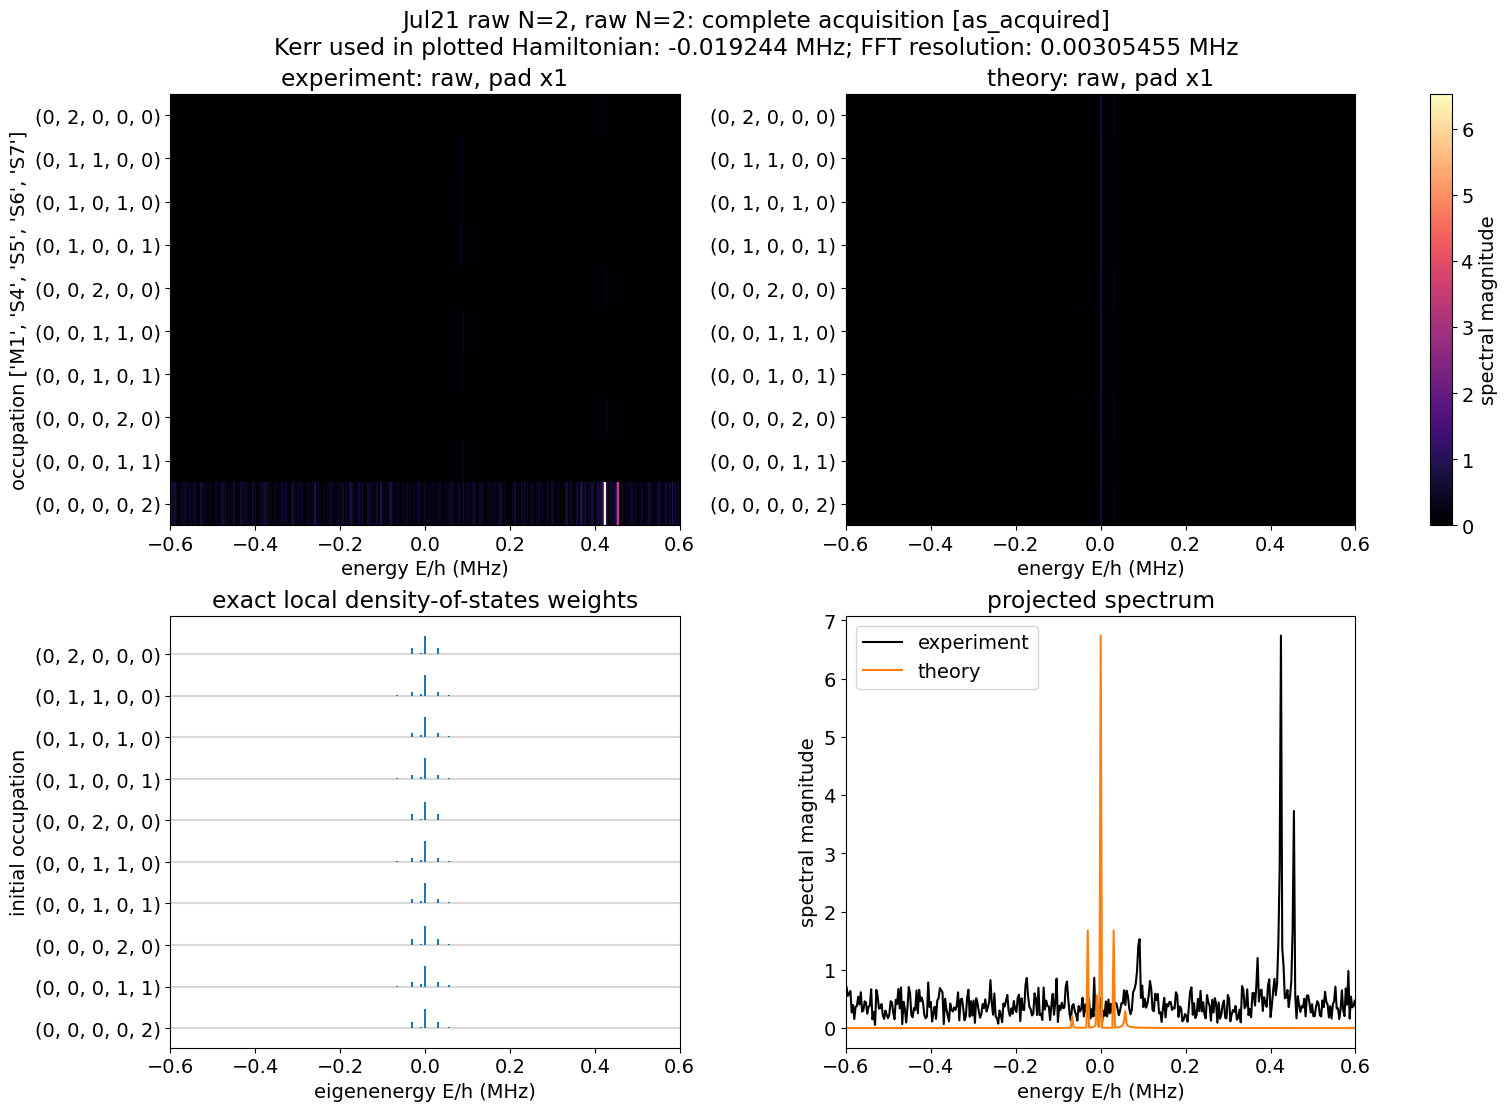

manual_kerr unavailable: no calibration HDF5 job pairs were loaded.


In [9]:
# Jul21 raw N=2 / raw N=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul21 raw N=2'
h5_group = 'raw N=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = [
    'JOB-20260721-00267', 'JOB-20260721-00271', 'JOB-20260721-00269', 'JOB-20260721-00273',
    'JOB-20260721-00275', 'JOB-20260721-00279', 'JOB-20260721-00277', 'JOB-20260721-00281',
    'JOB-20260721-00283', 'JOB-20260721-00287', 'JOB-20260721-00285', 'JOB-20260721-00289',
    'JOB-20260721-00291', 'JOB-20260721-00295', 'JOB-20260721-00293', 'JOB-20260721-00297',
    'JOB-20260721-00299', 'JOB-20260721-00303', 'JOB-20260721-00301', 'JOB-20260721-00305',
    'JOB-20260721-00307', 'JOB-20260721-00311', 'JOB-20260721-00309', 'JOB-20260721-00313',
    'JOB-20260721-00315', 'JOB-20260721-00319', 'JOB-20260721-00317', 'JOB-20260721-00321',
    'JOB-20260721-00323', 'JOB-20260721-00327', 'JOB-20260721-00325', 'JOB-20260721-00329',
    'JOB-20260721-00331', 'JOB-20260721-00335', 'JOB-20260721-00333', 'JOB-20260721-00337',
    'JOB-20260721-00339', 'JOB-20260721-00343', 'JOB-20260721-00341', 'JOB-20260721-00345',
]
h5_floquet_version = "CFG-FL-20260717-00028"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = True
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Jul22 N=1


### Jul22 N=1 / N=1


In [ ]:
# Jul22 N=1 / N=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=1'
h5_group = 'N=1'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 557, 566)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 577, 595)
h5_floquet_version = "CFG-FL-20260717-00028"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)


h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Jul22 N=2


### Jul22 N=2 / N=2


In [ ]:
# Jul22 N=2 / N=2: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=2'
h5_group = 'N=2'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 35, 64)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 215, 244)
h5_floquet_version = 'CFG-FL-20260722-00001'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Jul22 N=2 supplement


### Jul22 N=2 supplement / N=2 supplement


In [ ]:
# Jul22 N=2 supplement / N=2 supplement: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=2 supplement'
h5_group = 'N=2 supplement'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260722, 425, 426)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 452, 454)
h5_floquet_version = 'CFG-FL-20260722-00001'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Jul23 N=3


### Jul23 N=3 / N=3


In [ ]:
# Jul23 N=3 / N=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul23 N=3'
h5_group = 'N=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = (
    h5_job_ids(20260722, 683, 712)
    + h5_job_ids(20260723, 1, 40)
)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260723, 48, 85)
    + h5_job_ids(20260723, 87, 149)
)
h5_floquet_version = 'CFG-FL-20260722-00001'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Jul22 N=4


### Jul22 N=4 / N=4


In [ ]:
# Jul22 N=4 / N=4: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=4'
h5_group = 'N=4'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260721, 423, 432)
h5_spectroscopy_job_ids = h5_job_ids(20260722, 5, 14)
h5_floquet_version = "CFG-FL-20260717-00028"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Aug15 four-realization


### Aug15 four-realization / four-realization


In [ ]:
# Aug15 four-realization / four-realization: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15 four-realization'
h5_group = 'four-realization'
h5_project = '260814_qsim_encspec'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = h5_job_ids(20260815, 9, 16)
h5_floquet_version = "CFG-FL-20260814-00076"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Aug15-17 N=3 and disorder


### Aug15-17 N=3 and disorder / N=3


In [ ]:
# Aug15-17 N=3 and disorder / N=3: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug15-17 N=3 and disorder'
h5_group = 'N=3'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids = (
    h5_job_ids(20260815, 183, 242)
    + h5_job_ids(20260816, 1, 10)
)
h5_floquet_version ='CFG-FL-20260814-00076'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


### Aug15-17 N=3 and disorder / disorder realizations r=0..3


In [ ]:
# Aug15-17 N=3 and disorder: load and compare all realizations with shared calibration.
h5_name = 'Aug15-17 N=3 and disorder'
h5_project = '260526_qsim_darkmode'
h5_calibration_job_ids = h5_job_ids(20260815, 113, 182)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260816, 13, 32),
    1: h5_job_ids(20260816, 33, 52),
    2: h5_job_ids(20260816, 53, 72),
    3: h5_job_ids(20260817, 1, 20),
}
h5_floquet_version = 'CFG-FL-20260814-00076'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Aug26 four-realization


### Aug26 four-realization / four-realization


In [ ]:
# Aug26 four-realization / four-realization: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Aug26 four-realization'
h5_group = 'four-realization'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = []
h5_spectroscopy_job_ids = h5_job_ids(20260826, 67, 78)
# Lab note 8/20/2026: this exact JOB list follows the post-calibration config snapshot.
h5_floquet_version = 'CFG-FL-20260825-00097'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## Aug28-30 diagonal disorder


### Aug28-30 diagonal disorder / disorder realizations r=0..19


In [ ]:
# Aug28-30 diagonal disorder: load and compare all realizations with shared calibration.
h5_name = 'Aug28-30 diagonal disorder'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 289, 358)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260829, 16, 35),
    1: h5_job_ids(20260829, 36, 55),
    2: h5_job_ids(20260829, 56, 75),
    3: h5_job_ids(20260829, 76, 95),
    4: h5_job_ids(20260829, 96, 115),
    5: h5_job_ids(20260829, 116, 135),
    6: h5_job_ids(20260829, 136, 155),
    7: h5_job_ids(20260829, 156, 175),
    8: h5_job_ids(20260829, 176, 195),
    9: h5_job_ids(20260829, 196, 215),
    10: h5_job_ids(20260829, 216, 235),
    11: h5_job_ids(20260829, 236, 255),
    12: h5_job_ids(20260829, 256, 271) + h5_job_ids(20260830, 1, 4),
    13: h5_job_ids(20260830, 5, 24),
    14: h5_job_ids(20260830, 25, 44),
    15: h5_job_ids(20260830, 45, 64),
    16: h5_job_ids(20260830, 65, 84),
    17: h5_job_ids(20260830, 85, 104),
    18: h5_job_ids(20260830, 105, 124),
    19: h5_job_ids(20260830, 125, 135),
}
h5_floquet_version = 'CFG-FL-20260825-00097'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Sep10 K3.6 g29.2


### Sep10 K3.6 g29.2 / disorder realizations r=0..8


In [ ]:
# Sep10 K3.6 g29.2: load and compare all realizations with shared calibration.
h5_name = 'Sep10 K3.6 g29.2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260909, 152, 211) + h5_job_ids(20260910, 1, 10)

# r=0 includes Sep11 jobs without a verified Floquet version.
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260910, 31, 72) + h5_job_ids(20260911, 46, 87),
    1: h5_job_ids(20260912, 33, 136),
    2: h5_job_ids(20260912, 137, 241),
    3: h5_job_ids(20260912, 243, 347),
    4: h5_job_ids(20260912, 348, 419) + h5_job_ids(20260913, 1, 64),
    5: h5_job_ids(20260913, 65, 168),
    6: h5_job_ids(20260913, 169, 273),
    7: h5_job_ids(20260913, 274, 378),
    8: h5_job_ids(20260913, 380, 399) + h5_job_ids(20260914, 1, 84),
}
h5_floquet_version = 'CFG-FL-20260909-00042'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Sep07 K52.3 g29.2


### Sep07 K52.3 g29.2 / disorder realizations r=0..5


In [ ]:
# Sep07 K52.3 g29.2: load and compare all realizations with shared calibration.
h5_name = 'Sep07 K52.3 g29.2'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260907, 199, 268)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260907, 304, 333),
    1: h5_job_ids(20260907, 334, 363),
    2: h5_job_ids(20260907, 364, 393),
    3: h5_job_ids(20260907, 406, 415) + h5_job_ids(20260908, 1, 20),
    4: h5_job_ids(20260908, 21, 50),
    5: h5_job_ids(20260908, 51, 80),
}
h5_floquet_version = 'CFG-FL-20260906-00041'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Sep05 K3.6 g30


### Sep05 K3.6 g30 / disorder realizations r=0..1


In [ ]:
# Sep05 K3.6 g30: load and compare all realizations with shared calibration.
h5_name = 'Sep05 K3.6 g30'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260905, 75, 144)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260905, 145, 159),
    1: h5_job_ids(20260905, 160, 174),
}
h5_floquet_version = 'CFG-FL-20260905-00045' 
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Sep01 K44 g15


### Sep01 K44 g15 / disorder realizations r=0..4


In [ ]:
# Sep01 K44 g15: load and compare all realizations with shared calibration.
h5_name = 'Sep01 K44 g15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260831, 479, 548)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260901, 3, 12),
    1: h5_job_ids(20260901, 13, 22),
    2: h5_job_ids(20260901, 23, 32),
    3: h5_job_ids(20260901, 33, 42),
    4: h5_job_ids(20260901, 43, 52),
}
h5_floquet_version = 'CFG-FL-20260831-00092'
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Sep02 K20 g15


### Sep02 K20 g15 / disorder realizations r=0..4


In [ ]:
# Sep02 K20 g15: load and compare all realizations with shared calibration.
h5_name = 'Sep02 K20 g15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 1, 70)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260902, 71, 80),
    1: h5_job_ids(20260902, 81, 90),
    2: h5_job_ids(20260902, 91, 94) + ['JOB-20260902-00096', 'JOB-20260902-00097', 'JOB-20260902-00099', 'JOB-20260902-00100', 'JOB-20260902-00102', 'JOB-20260902-00103'],
    3: ['JOB-20260902-00105', 'JOB-20260902-00106', 'JOB-20260902-00108', 'JOB-20260902-00109', 'JOB-20260902-00111', 'JOB-20260902-00112', 'JOB-20260902-00114', 'JOB-20260902-00115', 'JOB-20260902-00117', 'JOB-20260902-00118'],
    4: ['JOB-20260902-00120', 'JOB-20260902-00121', 'JOB-20260902-00123', 'JOB-20260902-00124', 'JOB-20260902-00126', 'JOB-20260902-00127', 'JOB-20260902-00129', 'JOB-20260902-00130', 'JOB-20260902-00132', 'JOB-20260902-00133'],
}
h5_floquet_version = 'CFG-FL-20260901-00034'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Sep02-04 K3.6 g15


### Sep02-04 K3.6 g15 / disorder realizations r=0..18


In [ ]:
# Sep02-04 K3.6 g15: load and compare all realizations with shared calibration.
h5_name = 'Sep02-04 K3.6 g15'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260902, 768, 837)
h5_spectroscopy_job_ids_by_r = {
    0: ['JOB-20260902-00840', 'JOB-20260902-00841'] + h5_job_ids(20260903, 1, 13),
    1: h5_job_ids(20260903, 14, 28),
    2: h5_job_ids(20260903, 29, 43),
    3: h5_job_ids(20260903, 44, 58),
    4: ['JOB-20260903-00059', 'JOB-20260903-00060', 'JOB-20260903-00062', 'JOB-20260903-00063', 'JOB-20260903-00065', 'JOB-20260903-00066', 'JOB-20260903-00068', 'JOB-20260903-00069', 'JOB-20260903-00071', 'JOB-20260903-00072', 'JOB-20260903-00074', 'JOB-20260903-00075', 'JOB-20260903-00077', 'JOB-20260903-00078', 'JOB-20260903-00080'],
    5: ['JOB-20260903-00082', 'JOB-20260903-00083', 'JOB-20260903-00085', 'JOB-20260903-00086', 'JOB-20260903-00088', 'JOB-20260903-00089', 'JOB-20260903-00091', 'JOB-20260903-00092', 'JOB-20260903-00094', 'JOB-20260903-00095', 'JOB-20260903-00097', 'JOB-20260903-00098', 'JOB-20260903-00100', 'JOB-20260903-00101', 'JOB-20260903-00103'],
    6: ['JOB-20260903-00105', 'JOB-20260903-00106', 'JOB-20260903-00108', 'JOB-20260903-00109', 'JOB-20260903-00111', 'JOB-20260903-00112', 'JOB-20260903-00114', 'JOB-20260903-00115', 'JOB-20260903-00117', 'JOB-20260903-00118', 'JOB-20260903-00120', 'JOB-20260903-00121', 'JOB-20260903-00123', 'JOB-20260903-00124', 'JOB-20260903-00126'],
    7: ['JOB-20260903-00128', 'JOB-20260903-00129', 'JOB-20260903-00131', 'JOB-20260903-00132', 'JOB-20260903-00134', 'JOB-20260903-00135', 'JOB-20260903-00137', 'JOB-20260903-00138', 'JOB-20260903-00140', 'JOB-20260903-00141', 'JOB-20260903-00143', 'JOB-20260903-00144'] + h5_job_ids(20260903, 146, 148),
    8: h5_job_ids(20260903, 149, 163),
    9: h5_job_ids(20260903, 164, 178),
    10: h5_job_ids(20260903, 179, 193),
    11: h5_job_ids(20260903, 194, 203) + h5_job_ids(20260904, 1, 5),
    12: h5_job_ids(20260904, 6, 20),
    13: h5_job_ids(20260904, 21, 35),
    14: h5_job_ids(20260904, 36, 50),
    15: h5_job_ids(20260904, 51, 65),
    16: h5_job_ids(20260904, 66, 80),
    17: h5_job_ids(20260904, 81, 95),
    18: h5_job_ids(20260904, 96, 110),
}
h5_floquet_version = 'CFG-FL-20260902-00121'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## Aug28 N=1 disorderless

  station config: CFG-FL-20260828-00122 (local CSV + RFSoC clock snapshot)

Jul22 N=1: locating 10 spectroscopy HDF5 jobs
  spectroscopy headers: 10/10 in 0.0s
  calibration: loaded 10 HDF5 jobs
  spectroscopy arrays: 10 in 0.0s
  spectroscopy: loaded 10 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260828-00122 + HDF5 config + RFSoC clock
Spectroscopy job IDs used (10): JOB-20260828-00427, JOB-20260828-00428, JOB-20260828-00429, JOB-20260828-00430, JOB-20260828-00431, JOB-20260828-00432, JOB-20260828-00433, JOB-20260828-00434, JOB-20260828-00435, JOB-20260828-00436
Calibration job IDs used (10): JOB-20260828-00396, JOB-20260828-00397, JOB-20260828-00398, JOB-20260828-00399, JOB-20260828-00400, JOB-20260828-00401, JOB-20260828-00402, JOB-20260828-00403, JOB-20260828-00404, JOB-20260828-00405


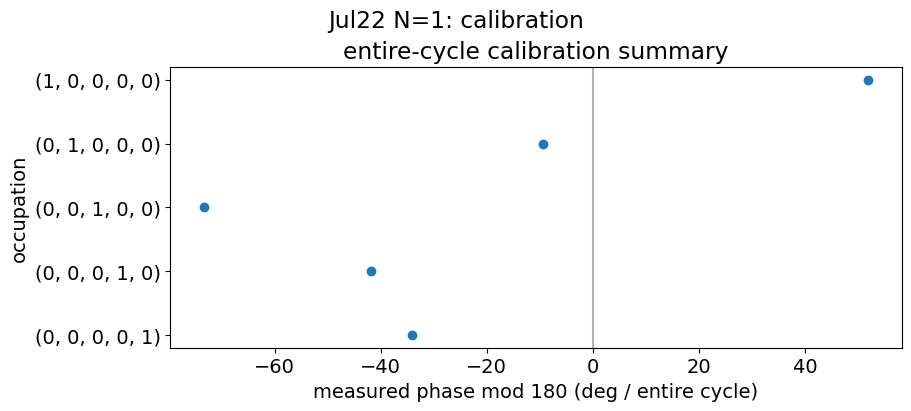

as_acquired theory self-Kerr: -0.04496 MHz (-44.96 kHz)
as_acquired theory g: M1-S2=0.0152727273 MHz (15.2727273 kHz), M1-S4=0.0152727273 MHz (15.2727273 kHz), M1-S5=0.0152727273 MHz (15.2727273 kHz), M1-S6=0.0152727273 MHz (15.2727273 kHz)


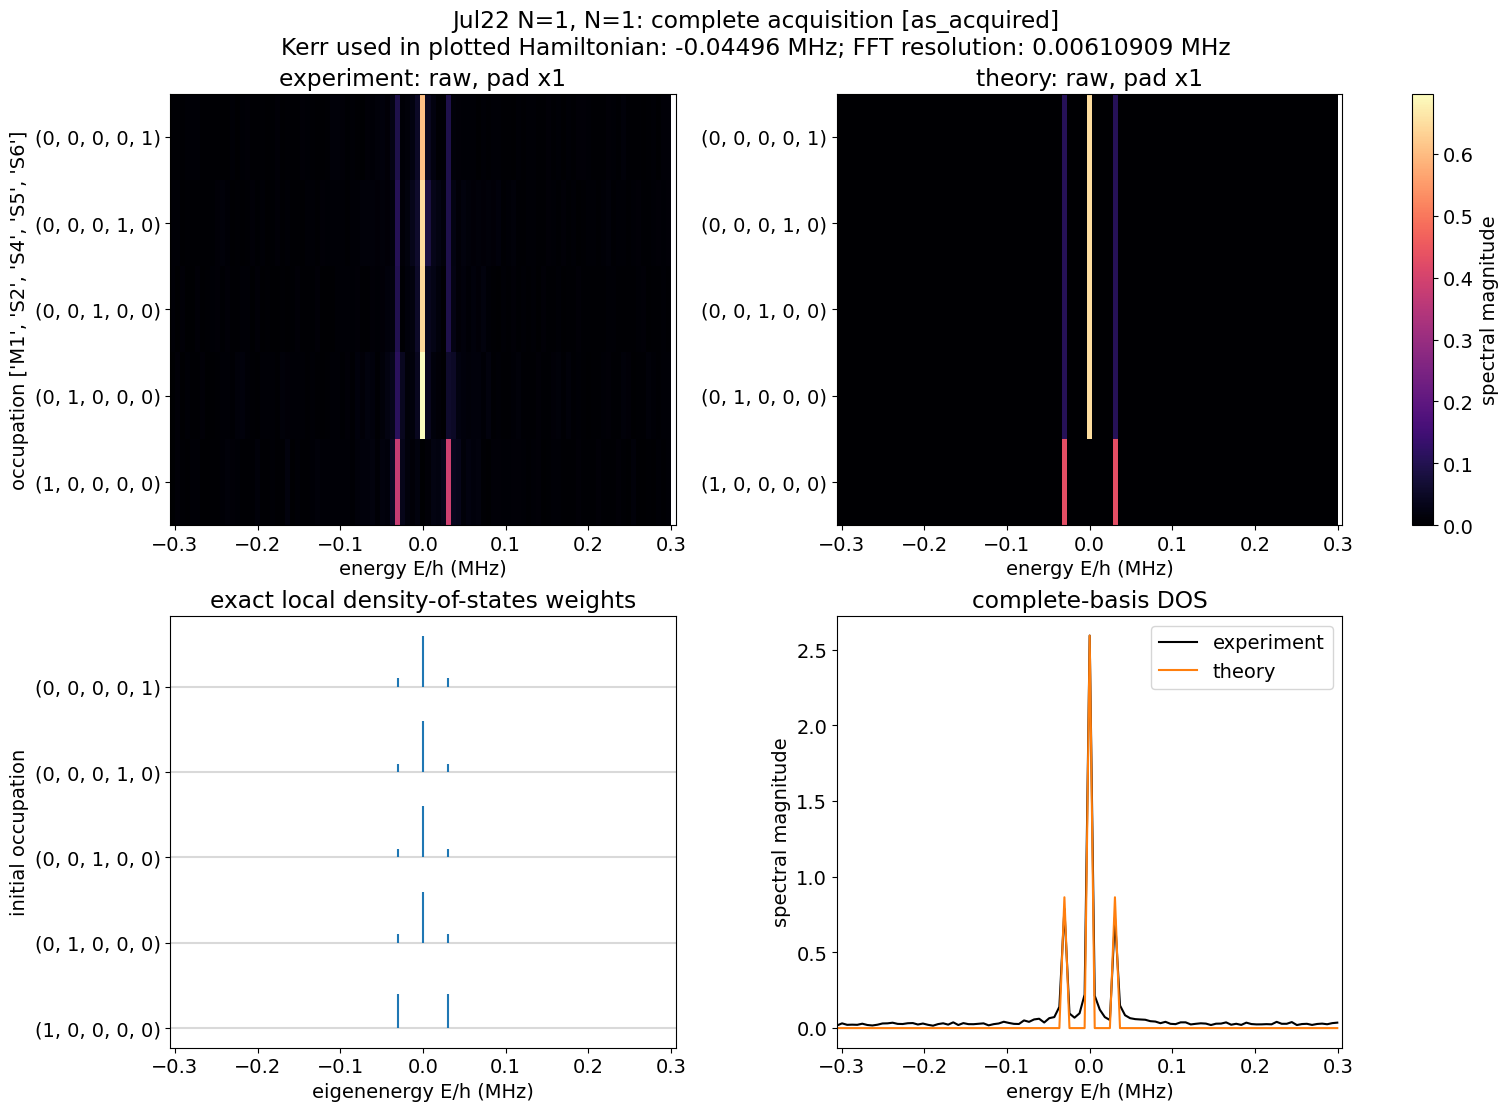

manual_kerr failed: ValueError: legacy disagrees with the saved analyzer phase application sign


In [10]:
# Jul22 N=1 / N=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'Jul22 N=1'
h5_group = 'N=1'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260828, 396, 405)
h5_spectroscopy_job_ids = h5_job_ids(20260828, 427, 436)
h5_floquet_version = "CFG-FL-20260828-00122"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)


h5_phase_legacy = True  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


## (Quality Concern) Aug24-25 K=45 kHz

In [31]:
query_which_config_used(h5_calibration_job_ids[0])[2]

['CFG-HW-20260824-00001', 'CFG-M1-20260824-00011', 'CFG-FL-20260824-00073', 'CFG-MP-20260121-00001']


'CFG-FL-20260824-00073'

In [37]:
# Jul22 N=1 / N=1: only the job IDs below are loaded and plotted.
# Calibration and spectroscopy are read from HDF5 in this cell.
h5_name = 'whatever'
h5_group = 'N=3'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260824, 540, 569)+h5_job_ids(20260825, 1, 40)
h5_spectroscopy_job_ids = h5_job_ids(20260825, 47, 116)
h5_floquet_version = "CFG-FL-20260824-00073"
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = False

h5_calibration_expt, h5_spectroscopy_expt, h5_info = h5_load_group(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids,
    station=h5_station,
    legacy_plus=h5_legacy_plus, search_other_projects=h5_search_other_projects,
)


h5_phase_legacy = None  # True: saved slope was added; False: subtracted.
h5_spectrum, h5_manual_spectrum = h5_plot_frames(
    h5_name, h5_group, h5_info, h5_calibration_expt, h5_spectroscopy_expt,
    h5_spectroscopy_job_ids, phase_legacy=h5_phase_legacy,
)


IndentationError: unexpected indent (130872251.py, line 7)

## (Quality Concern) Aug 19 K = 45 kHz

  station config: CFG-FL-20260818-00173 (local CSV + RFSoC clock snapshot)

Aug19 whatisthis disorder: locating 60 spectroscopy jobs across 3 realizations


  HDF5 headers: 60/60 spectroscopy, 70/70 calibration in 0.3s

Aug19 whatisthis disorder / r=0: locating 20 spectroscopy HDF5 jobs
  spectroscopy headers: 20/20 in 0.0s
  calibration: loaded 70 HDF5 jobs
  spectroscopy arrays: 20 in 0.1s
  spectroscopy: loaded 20 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260818-00173 + HDF5 config + RFSoC clock
Disorder strength for r=0: 50 kHz (saved disorder_strength_kHz)


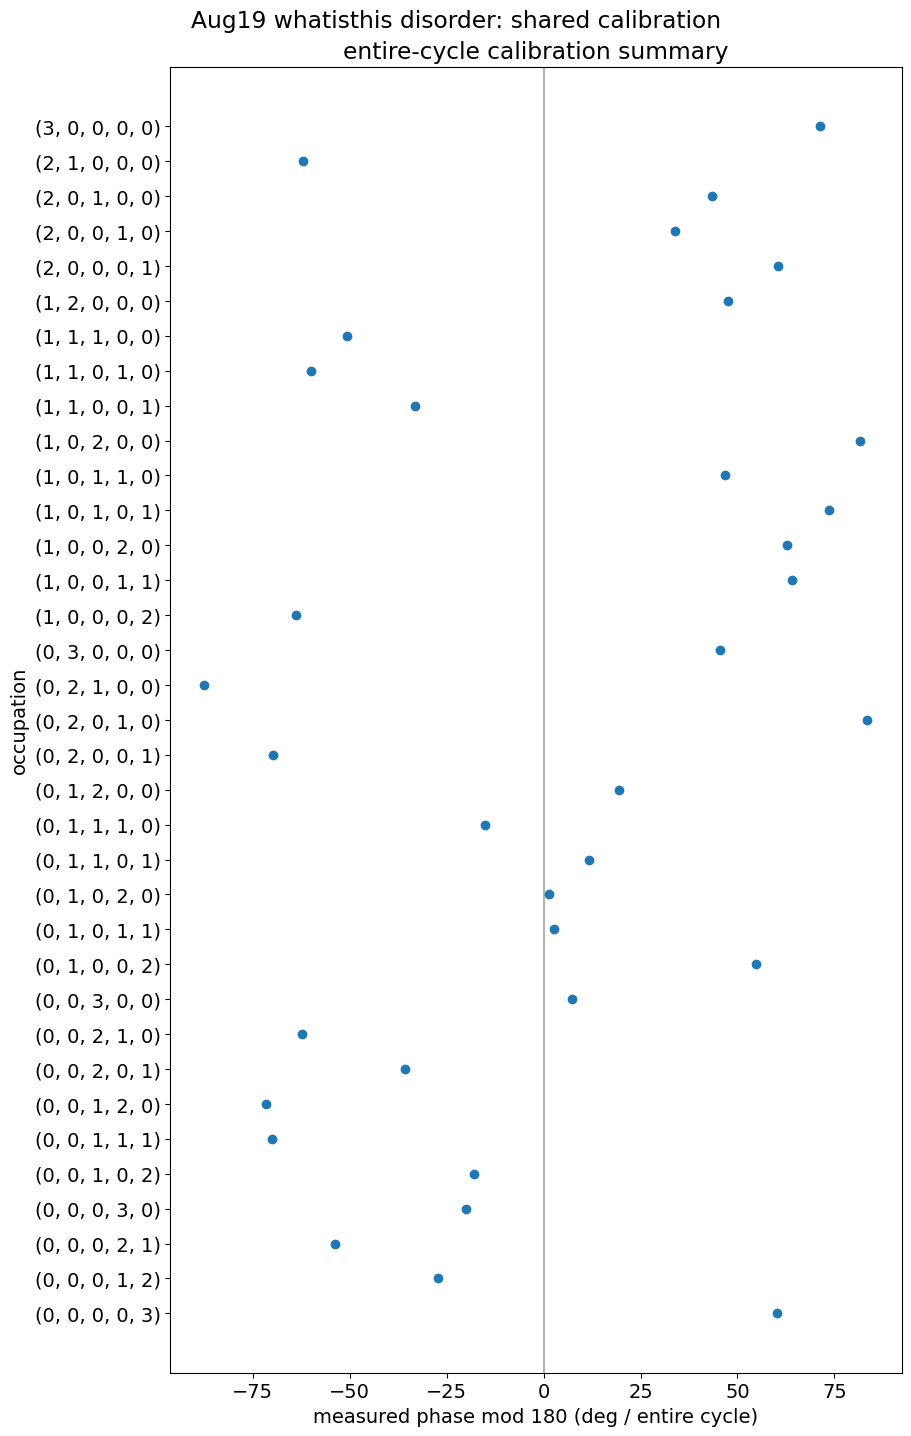

r=0 as_acquired theory self-Kerr: -0.04496 MHz (-44.96 kHz)
r=0 as_acquired theory g: M1-S2=0.0181621622 MHz (18.1621622 kHz), M1-S3=0.0181621622 MHz (18.1621622 kHz), M1-S4=0.0181621622 MHz (18.1621622 kHz), M1-S5=0.0181621622 MHz (18.1621622 kHz)
r=0 manual_kerr theory self-Kerr: -0.04496 MHz (-44.96 kHz)
r=0 manual_kerr theory g: M1-S2=0.0181621622 MHz (18.1621622 kHz), M1-S3=0.0181621622 MHz (18.1621622 kHz), M1-S4=0.0181621622 MHz (18.1621622 kHz), M1-S5=0.0181621622 MHz (18.1621622 kHz)

Aug19 whatisthis disorder / r=1: locating 20 spectroscopy HDF5 jobs
  spectroscopy headers: 20/20 in 0.0s
  calibration: reused 70 HDF5 jobs
  spectroscopy arrays: 20 in 0.1s
  spectroscopy: loaded 20 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260818-00173 + HDF5 config + RFSoC clock
Disorder strength for r=1: 50 kHz (saved disorder_strength_kHz)
r=1 as_acquired theory self-Kerr: -0.04496 MHz (-44.96 kHz)
r=1 as_acquired theory g: M1-S2=0.0181621622 MHz (18.1621622 kHz), M1-S3=0.0181621622 MHz 

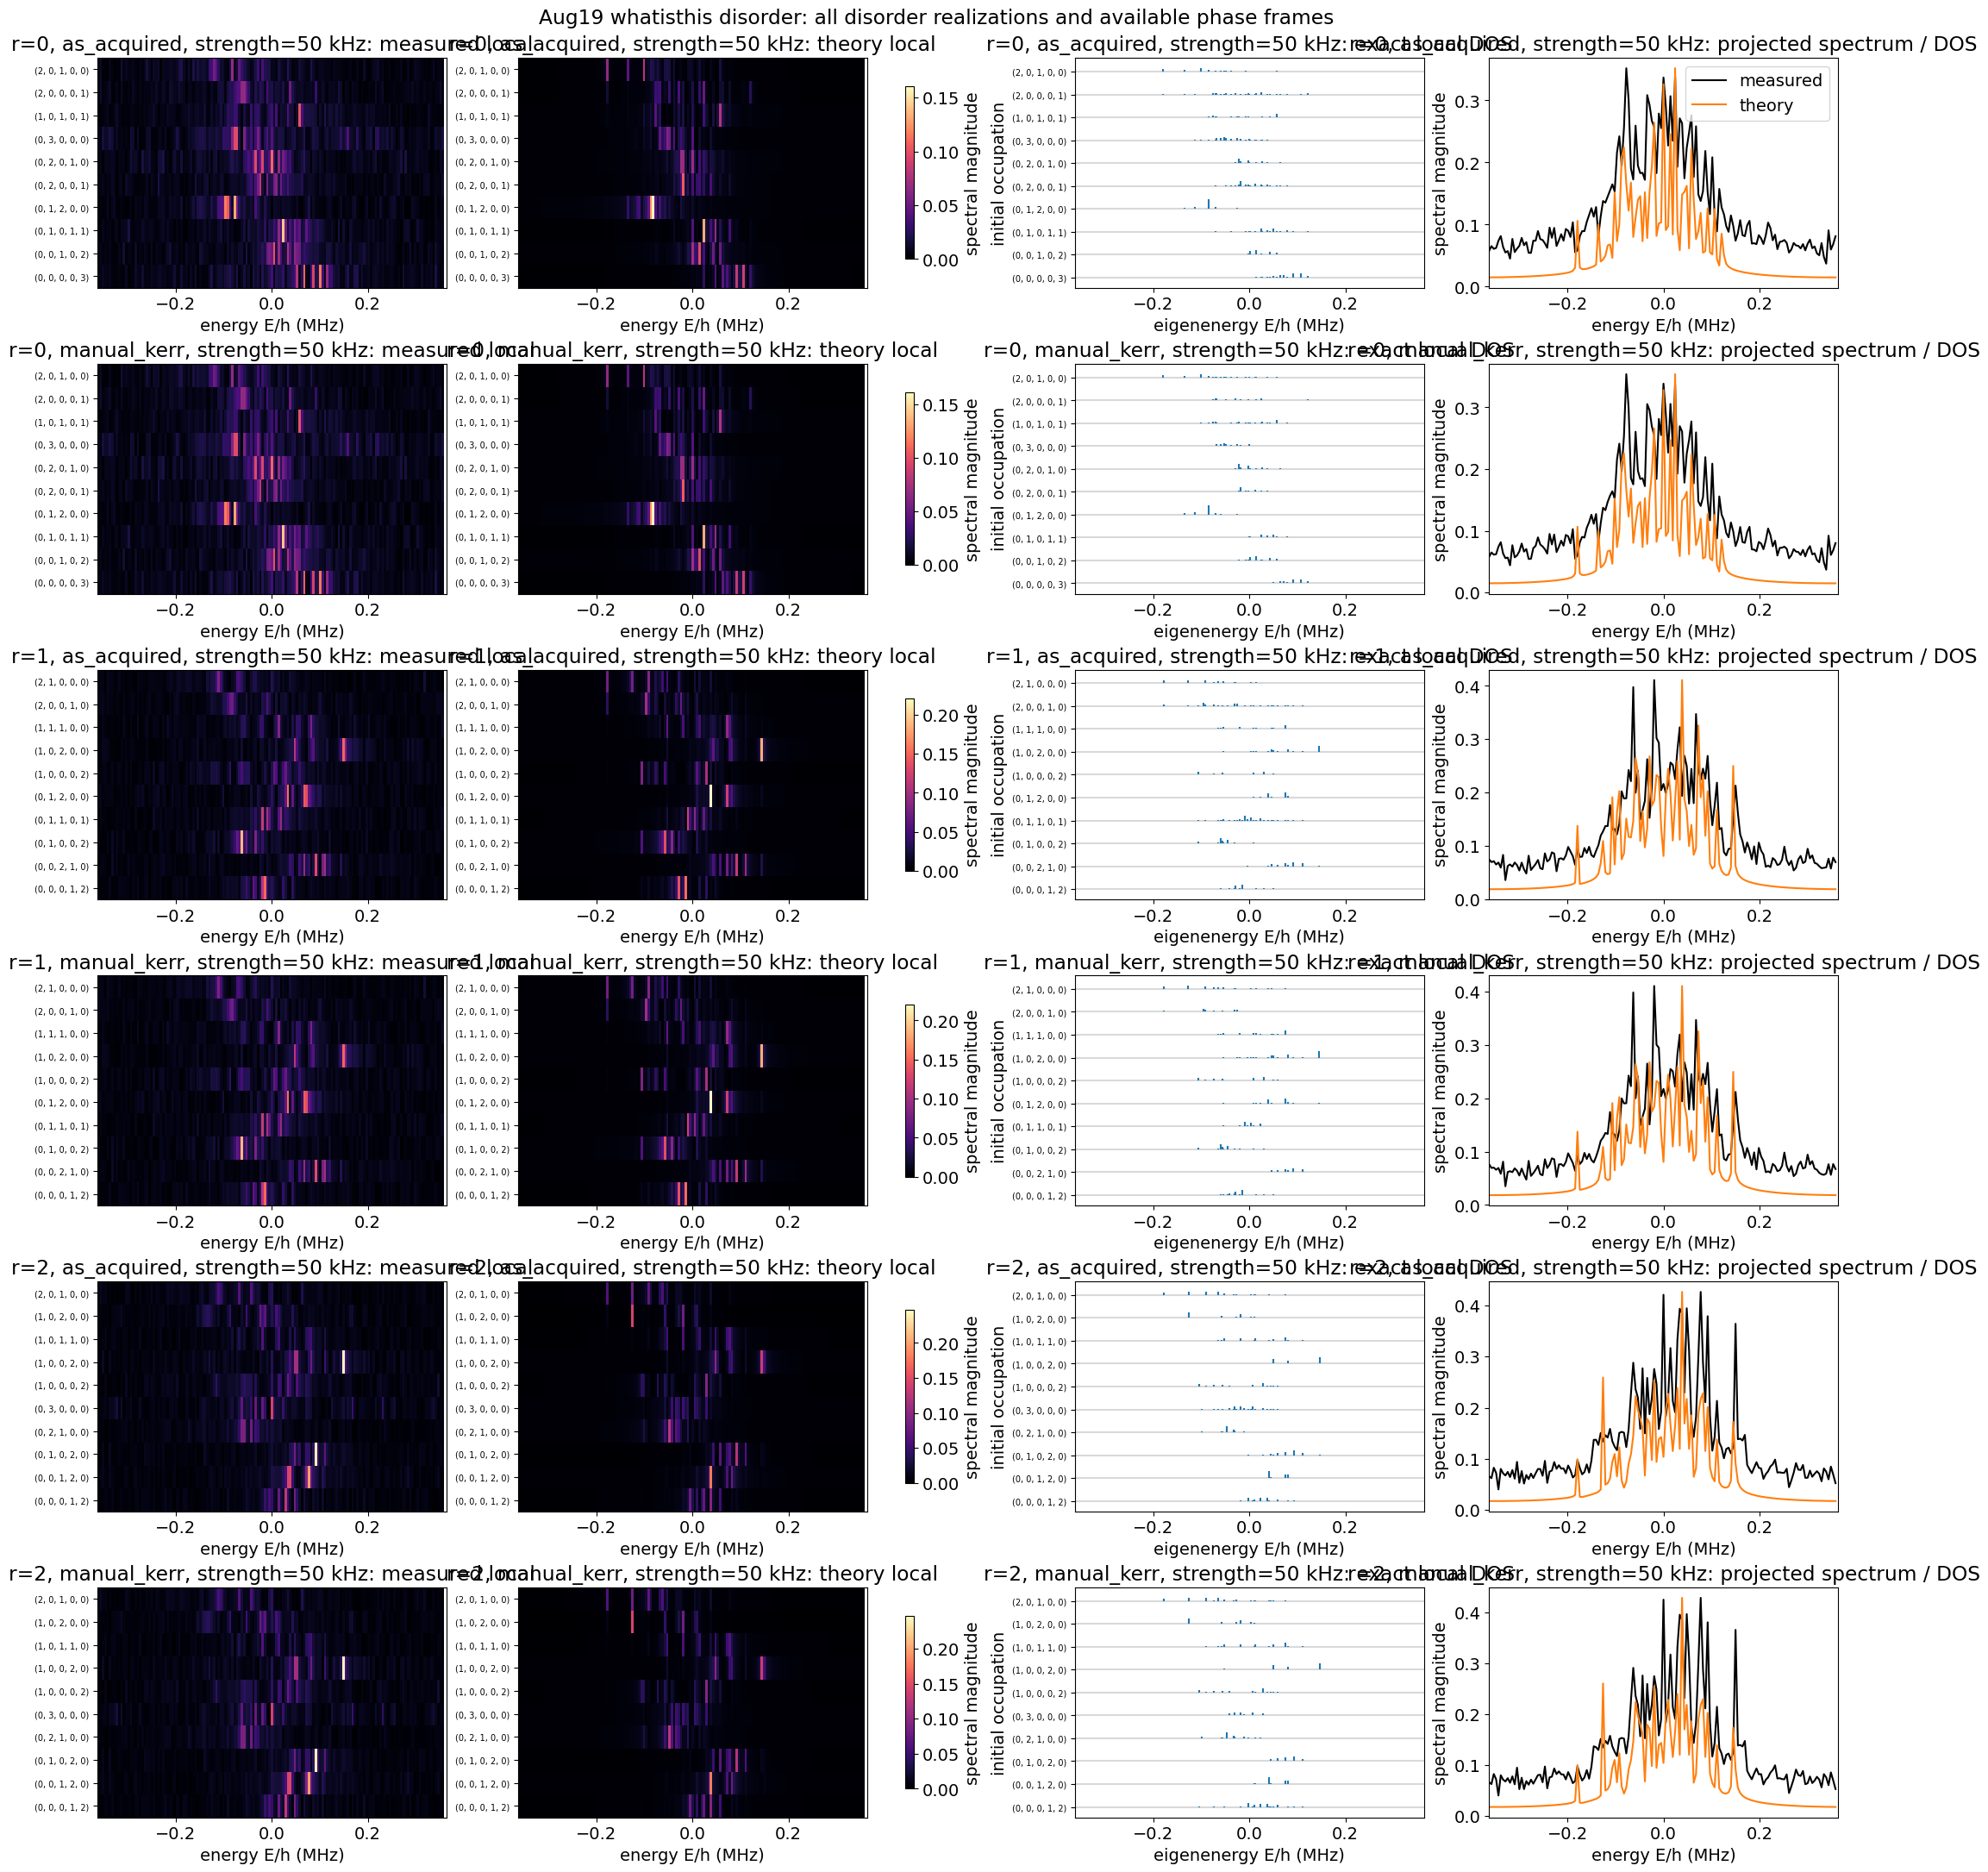

In [36]:
# Aug28-30 diagonal disorder: load and compare all realizations with shared calibration.
print(query_which_config_used(h5_calibration_job_ids[0])[2])
h5_name = 'Aug19 whatisthis disorder'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260819, 15, 84)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260819, 85, 104),
    1: h5_job_ids(20260819, 105, 124),
    2: h5_job_ids(20260819, 125, 144),
}
h5_floquet_version = 'CFG-FL-20260818-00173'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = True
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)


## (Quality Concern) Aug 27 K = 17 kHz

In [48]:
print(h5_calibration_job_ids)

['JOB-20260825-00694', 'JOB-20260825-00695', 'JOB-20260825-00698', 'JOB-20260825-00699', 'JOB-20260825-00700', 'JOB-20260825-00701', 'JOB-20260825-00702', 'JOB-20260825-00703', 'JOB-20260825-00712', 'JOB-20260825-00713', 'JOB-20260825-00714', 'JOB-20260825-00715', 'JOB-20260825-00716', 'JOB-20260825-00717', 'JOB-20260825-00718', 'JOB-20260825-00719', 'JOB-20260825-00720', 'JOB-20260825-00721', 'JOB-20260825-00722', 'JOB-20260825-00723', 'JOB-20260826-00011', 'JOB-20260826-00012', 'JOB-20260826-00013', 'JOB-20260826-00014', 'JOB-20260826-00015', 'JOB-20260826-00016', 'JOB-20260826-00017', 'JOB-20260826-00018', 'JOB-20260826-00019', 'JOB-20260826-00020', 'JOB-20260826-00021', 'JOB-20260826-00022', 'JOB-20260826-00023', 'JOB-20260826-00024', 'JOB-20260826-00025', 'JOB-20260826-00026', 'JOB-20260826-00027', 'JOB-20260826-00028', 'JOB-20260826-00029', 'JOB-20260826-00030', 'JOB-20260826-00274', 'JOB-20260826-00275', 'JOB-20260826-00276', 'JOB-20260826-00277', 'JOB-20260826-00278', 'JOB-2026

['CFG-HW-20260825-00103', 'CFG-M1-20260825-00063', 'CFG-FL-20260825-00097', 'CFG-MP-20260121-00001']
CFG-FL-20260825-00097
  station config: CFG-FL-20260825-00097 (local CSV + RFSoC clock snapshot)

Aug19 whatisthis disorder: locating 64 spectroscopy jobs across 3 realizations
  HDF5 headers: 60/64 spectroscopy, 70/70 calibration in 0.1s

Aug19 whatisthis disorder / r=0: locating 20 spectroscopy HDF5 jobs
  spectroscopy headers: 20/20 in 0.0s
  calibration: no matching paired HDF5 jobs
  spectroscopy arrays: 20 in 0.1s
  spectroscopy: loaded 20 HDF5 jobs
  T/g source: Floquet CSV CFG-FL-20260825-00097 + HDF5 config + RFSoC clock
Disorder strength for r=0: 20 kHz (saved diagonal_disorder_strength_kHz)
r=0 as_acquired theory self-Kerr: -0.0205 MHz (-20.5 kHz)
r=0 as_acquired theory g: M1-S4=0.0152727273 MHz (15.2727273 kHz), M1-S5=0.0152727273 MHz (15.2727273 kHz), M1-S6=0.0152727273 MHz (15.2727273 kHz), M1-S7=0.0152727273 MHz (15.2727273 kHz)
r=0 manual_kerr unavailable: no calibration

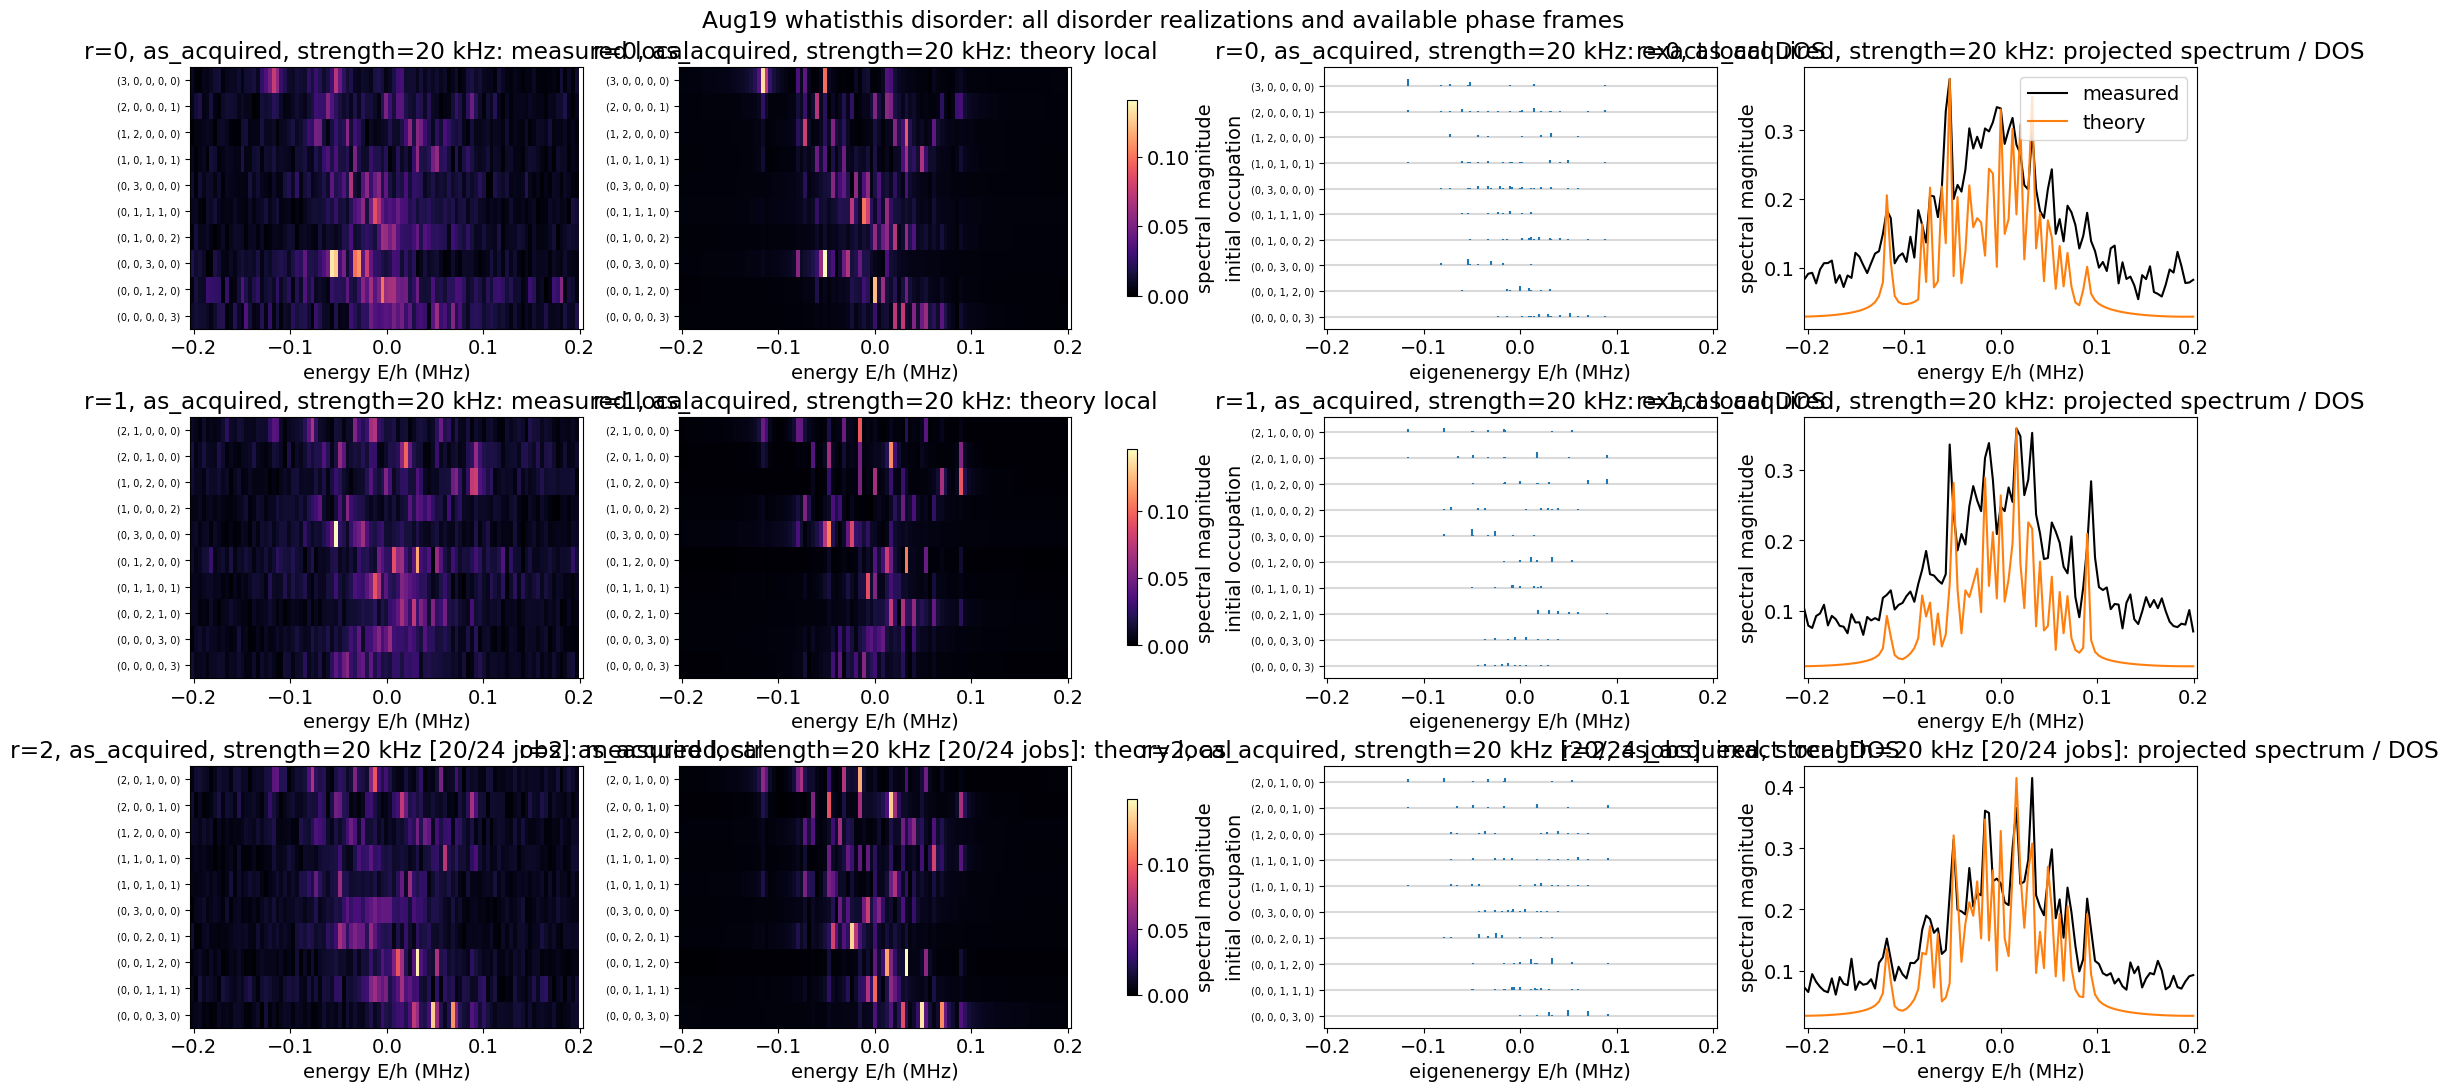

In [46]:
# Aug28-30 diagonal disorder: load and compare all realizations with shared calibration.
print(query_which_config_used(h5_calibration_job_ids[0])[2])
h5_name = 'Aug19 whatisthis disorder'
h5_project = '260818_qsim_spectroscopy'
h5_calibration_job_ids = h5_job_ids(20260825, 694, 695) + h5_job_ids(20260825, 698, 703)+ h5_job_ids(20260825, 712, 723)+ h5_job_ids(20260826, 11, 30)+ h5_job_ids(20260826, 274, 303)
h5_spectroscopy_job_ids_by_r = {
    0: h5_job_ids(20260827, 79, 98),
    1: h5_job_ids(20260827, 99, 118),
    2: h5_job_ids(20260827, 119, 142),
}
h5_floquet_version = 'CFG-FL-20260825-00097'  # Set the matching acquisition Floquet config version here.
h5_station = h5_load_offline_station(h5_floquet_version)
h5_legacy_plus = False
h5_search_other_projects = None
h5_phase_legacy = None  # True: saved slope was added; False: subtracted.

h5_disorder_records = h5_load_disorder_series(
    h5_name, h5_project, h5_calibration_job_ids, h5_spectroscopy_job_ids_by_r,
    station=h5_station, legacy_plus=h5_legacy_plus,
    search_other_projects=h5_search_other_projects,
    phase_legacy=h5_phase_legacy,
)
